# Fase 3.3 — Domain Shift: Datos Sintéticos vs. NHANES
**Objetivo:** Cuantificar cuánto se pierde al entrenar con datos sintéticos y evaluar en datos reales.

Se comparan tres escenarios:
1. **Sintético → Sintético**: entrena y evalúa en datos sintéticos (Kaggle)
2. **Sintético → NHANES**: entrena en sintético, evalúa en NHANES (domain shift)
3. **NHANES → NHANES**: entrena y evalúa en NHANES (línea base real)

La diferencia entre el escenario 2 y 3 cuantifica exactamente el costo del domain shift.

## 0. Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.base import clone



## 1. Carga de datasets

In [2]:
# Dataset sintético (Kaggle)
df_sint = pd.read_csv(r"../data/Blood_samples_dataset_balanced_2(f).csv")
print(f'Sintético shape  : {df_sint.shape}')
print(f'Clases sintético : {df_sint["Disease"].value_counts().to_dict()}')

# Dataset NHANES etiquetado
df_nhanes = pd.read_csv(r"../data_test/NHANES_2017_2020_labeled_diseases.csv")
print(f'\nNHANES shape     : {df_nhanes.shape}')
print(f'Clases NHANES    : {df_nhanes["condition"].value_counts().to_dict()}')

Sintético shape  : (2351, 25)
Clases sintético : {'Anemia': 623, 'Healthy': 556, 'Diabetes': 540, 'Thalasse': 509, 'Thromboc': 123}

NHANES shape     : (4812, 11)
Clases NHANES    : {'healthy': 3766, 'borderline': 410, 'thalassemia': 347, 'thrombocytopenia': 204, 'anemia': 85}


## 2. Alineación de columnas y etiquetas

Se usan solo las columnas compartidas entre ambos datasets.
Las etiquetas se mapean a un espacio común.

In [3]:
# Columnas compartidas (features)
cols_nhanes = set(df_nhanes.columns) - {'condition'}
cols_sint   = set(df_sint.columns)   - {'Disease'}
cols_comunes = sorted(list(cols_nhanes & cols_sint))

print(f'Columnas en NHANES   : {len(cols_nhanes)}')
print(f'Columnas en sintético: {len(cols_sint)}')
print(f'Columnas compartidas : {len(cols_comunes)}')
print(f'\nFeatures usadas: {cols_comunes}')

Columnas en NHANES   : 10
Columnas en sintético: 24
Columnas compartidas : 10

Features usadas: ['ALT', 'HDL Cholesterol', 'Heart Rate', 'Hematocrit', 'Mean Corpuscular Hemoglobin', 'Mean Corpuscular Hemoglobin Concentration', 'Mean Corpuscular Volume', 'Platelets', 'Red Blood Cells', 'White Blood Cells']


In [4]:
# Mapeo de etiquetas al mismo espacio
# Sintético: Anemia, Healthy, Diabetes, Thalasse, Thromboc
# NHANES   : anemia, healthy, borderline, thalassemia, thrombocytopenia

mapa_sint = {
    'Anemia'  : 'anemia',
    'Healthy' : 'healthy',
    'Diabetes': 'other',       # No existe en NHANES con estas features
    'Thalasse': 'thalassemia',
    'Thromboc': 'thrombocytopenia'
}

mapa_nhanes = {
    'anemia'          : 'anemia',
    'healthy'         : 'healthy',
    'borderline'      : 'other',
    'thalassemia'     : 'thalassemia',
    'thrombocytopenia': 'thrombocytopenia'
}

df_sint['label']   = df_sint['Disease'].map(mapa_sint)
df_nhanes['label'] = df_nhanes['condition'].map(mapa_nhanes)

# Eliminar clase 'other' para mantener comparabilidad
df_sint_clean   = df_sint[df_sint['label'] != 'other'].copy()
df_nhanes_clean = df_nhanes[df_nhanes['label'] != 'other'].copy()

print('Distribución final sintético:')
print(df_sint_clean['label'].value_counts())
print('\nDistribución final NHANES:')
print(df_nhanes_clean['label'].value_counts())

# Clases comunes
clases_comunes = sorted(list(
    set(df_sint_clean['label'].unique()) & set(df_nhanes_clean['label'].unique())
))
print(f'\nClases comunes para comparación: {clases_comunes}')

Distribución final sintético:
label
anemia              623
healthy             556
thalassemia         509
thrombocytopenia    123
Name: count, dtype: int64

Distribución final NHANES:
label
healthy             3766
thalassemia          347
thrombocytopenia     204
anemia                85
Name: count, dtype: int64

Clases comunes para comparación: ['anemia', 'healthy', 'thalassemia', 'thrombocytopenia']


## 3. Preparación de features

In [5]:
le = LabelEncoder()
le.fit(clases_comunes)

# Features y etiquetas sintético
X_sint = df_sint_clean[cols_comunes].copy()
y_sint = le.transform(df_sint_clean['label'])

# Features y etiquetas NHANES
X_nhanes = df_nhanes_clean[cols_comunes].copy()
y_nhanes = le.transform(df_nhanes_clean['label'])

print(f'X sintético : {X_sint.shape}')
print(f'X NHANES    : {X_nhanes.shape}')
print(f'Clases      : {list(le.classes_)}')

# Partición NHANES para escenario 3
X_nh_train, X_nh_test, y_nh_train, y_nh_test = train_test_split(
    X_nhanes, y_nhanes, test_size=0.30, stratify=y_nhanes, random_state=42
)

# Partición sintético para escenario 1
X_sint_train, X_sint_test, y_sint_train, y_sint_test = train_test_split(
    X_sint, y_sint, test_size=0.30, stratify=y_sint, random_state=42
)

print(f'\nTrain sintético: {len(y_sint_train)} | Test sintético: {len(y_sint_test)}')
print(f'Train NHANES   : {len(y_nh_train)}   | Test NHANES   : {len(y_nh_test)}')

X sintético : (1811, 10)
X NHANES    : (4402, 10)
Clases      : [np.str_('anemia'), np.str_('healthy'), np.str_('thalassemia'), np.str_('thrombocytopenia')]

Train sintético: 1267 | Test sintético: 544
Train NHANES   : 3081   | Test NHANES   : 1321


## 4. Función de entrenamiento y evaluación

In [6]:
def entrenar_evaluar(X_train, y_train, X_test, y_test, nombre_experimento):
    """Imputa, escala, entrena RF y evalúa. Retorna dict con métricas."""
    imputer = SimpleImputer(strategy='median')
    scaler  = StandardScaler()
    
    X_tr = scaler.fit_transform(imputer.fit_transform(X_train))
    X_te = scaler.transform(imputer.transform(X_test))
    
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_train)
    y_pred = rf.predict(X_te)
    
    acc    = accuracy_score(y_test, y_pred)
    f1_mac = f1_score(y_test, y_pred, average='macro',    zero_division=0)
    f1_w   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f'\n--- {nombre_experimento} ---')
    print(f'Accuracy   : {acc:.4f}')
    print(f'F1 Macro   : {f1_mac:.4f}')
    print(f'F1 Weighted: {f1_w:.4f}')
    
    return {
        'Experimento': nombre_experimento,
        'Accuracy'   : round(acc,    4),
        'F1-Macro'   : round(f1_mac, 4),
        'F1-Weighted': round(f1_w,   4),
        'y_test'     : y_test,
        'y_pred'     : y_pred
    }


## 5. Escenario 1 — Sintético → Sintético (referencia)

In [7]:
r1 = entrenar_evaluar(
    X_sint_train, y_sint_train,
    X_sint_test,  y_sint_test,
    'Sintético → Sintético'
)


--- Sintético → Sintético ---
Accuracy   : 1.0000
F1 Macro   : 1.0000
F1 Weighted: 1.0000


## 6. Escenario 2 — Sintético → NHANES (domain shift)

In [8]:
r2 = entrenar_evaluar(
    X_sint,    y_sint,      # Entrena con TODO el sintético
    X_nh_test, y_nh_test,   # Evalúa en test NHANES
    'Sintético → NHANES (Domain Shift)'
)


--- Sintético → NHANES (Domain Shift) ---
Accuracy   : 0.0787
F1 Macro   : 0.0365
F1 Weighted: 0.0115


## 7. Escenario 3 — NHANES → NHANES (línea base real)

In [9]:
r3 = entrenar_evaluar(
    X_nh_train, y_nh_train,
    X_nh_test,  y_nh_test,
    'NHANES → NHANES'
)


--- NHANES → NHANES ---
Accuracy   : 0.9992
F1 Macro   : 0.9967
F1 Weighted: 0.9992


## 8. Tabla resumen y visualización

TABLA RESUMEN — DOMAIN SHIFT
                      Experimento  Accuracy  F1-Macro  F1-Weighted
            Sintético → Sintético    1.0000    1.0000       1.0000
Sintético → NHANES (Domain Shift)    0.0787    0.0365       0.0115
                  NHANES → NHANES    0.9992    0.9967       0.9992

Costo del domain shift (NHANES→NHANES vs Sintético→NHANES):
  Degradación Accuracy : +0.9205 puntos
  Degradación F1-Macro : +0.9602 puntos


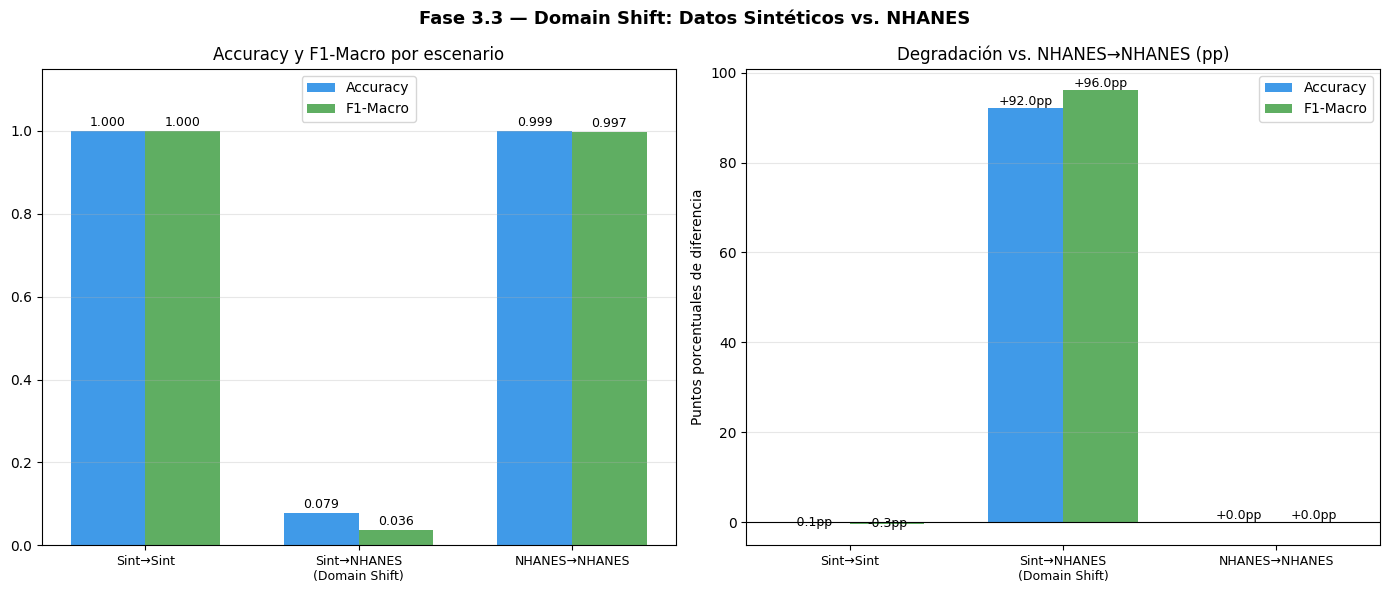

In [10]:
resultados = [r1, r2, r3]
df_res = pd.DataFrame([{
    'Experimento': r['Experimento'],
    'Accuracy'   : r['Accuracy'],
    'F1-Macro'   : r['F1-Macro'],
    'F1-Weighted': r['F1-Weighted']
} for r in resultados])

# Calcular degradación del escenario 2 vs 3
degr_acc = r3['Accuracy'] - r2['Accuracy']
degr_f1  = r3['F1-Macro'] - r2['F1-Macro']

print('='*70)
print('TABLA RESUMEN — DOMAIN SHIFT')
print('='*70)
print(df_res.to_string(index=False))
print(f'\nCosto del domain shift (NHANES→NHANES vs Sintético→NHANES):')
print(f'  Degradación Accuracy : {degr_acc:+.4f} puntos')
print(f'  Degradación F1-Macro : {degr_f1:+.4f} puntos')

df_res.to_csv('../resultados_fase3_3.csv', index=False)

# Visualización
os.makedirs('../img', exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Fase 3.3 — Domain Shift: Datos Sintéticos vs. NHANES',
             fontsize=13, fontweight='bold')

colores_escenarios = ['#7B1FA2', '#E53935', '#2196F3']
nombres_cortos     = ['Sint→Sint', 'Sint→NHANES\n(Domain Shift)', 'NHANES→NHANES']

# Gráfica 1: Accuracy y F1
ax1 = axes[0]
x     = np.arange(3)
width = 0.35
acc_vals = [r['Accuracy'] for r in resultados]
f1_vals  = [r['F1-Macro'] for r in resultados]

bars1 = ax1.bar(x - width/2, acc_vals, width, label='Accuracy',  color='#1E88E5', alpha=0.85)
bars2 = ax1.bar(x + width/2, f1_vals,  width, label='F1-Macro',  color='#43A047', alpha=0.85)

for bars, vals in [(bars1, acc_vals), (bars2, f1_vals)]:
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=9)

ax1.set_xticks(x)
ax1.set_xticklabels(nombres_cortos, fontsize=9)
ax1.set_ylim(0, 1.15)
ax1.set_title('Accuracy y F1-Macro por escenario')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Gráfica 2: Degradación relativa
ax2 = axes[1]
base_acc = r3['Accuracy']
base_f1  = r3['F1-Macro']
degr_accs = [(base_acc - r['Accuracy'])*100 for r in resultados]
degr_f1s  = [(base_f1  - r['F1-Macro'])*100 for r in resultados]

bars3 = ax2.bar(x - width/2, degr_accs, width, label='Accuracy', color='#1E88E5', alpha=0.85)
bars4 = ax2.bar(x + width/2, degr_f1s,  width, label='F1-Macro', color='#43A047', alpha=0.85)

for bars, vals in [(bars3, degr_accs), (bars4, degr_f1s)]:
    for bar, v in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (0.1 if v >= 0 else -1.5),
                 f'{v:+.1f}pp', ha='center', va='bottom', fontsize=9)

ax2.set_xticks(x)
ax2.set_xticklabels(nombres_cortos, fontsize=9)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Degradación vs. NHANES→NHANES (pp)')
ax2.set_ylabel('Puntos porcentuales de diferencia')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../img/fase3_3_domain_shift.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Interpretación automática

In [11]:
print('='*65)
print('INTERPRETACIÓN — DOMAIN SHIFT')
print('='*65)

print(f'\nEscenario 1 (Sint→Sint)         : Acc={r1["Accuracy"]:.4f} | F1={r1["F1-Macro"]:.4f}')
print(f'Escenario 2 (Sint→NHANES)       : Acc={r2["Accuracy"]:.4f} | F1={r2["F1-Macro"]:.4f}')
print(f'Escenario 3 (NHANES→NHANES)     : Acc={r3["Accuracy"]:.4f} | F1={r3["F1-Macro"]:.4f}')

costo_acc = (r3['Accuracy'] - r2['Accuracy']) * 100
costo_f1  = (r3['F1-Macro'] - r2['F1-Macro']) * 100

print(f'\nCosto del domain shift:')
print(f'  Accuracy : {costo_acc:+.2f} pp (entrenar en NHANES gana {costo_acc:.2f} puntos)')
print(f'  F1-Macro : {costo_f1:+.2f} pp')

if costo_acc > 10:
    print('\n✗ Domain shift SEVERO — los datos sintéticos no generalizan bien a NHANES.')
    print('  Conclusión: el modelo debe entrenarse con datos reales para uso clínico.')
elif costo_acc > 5:
    print('\n~ Domain shift MODERADO — pérdida de rendimiento notable pero no crítica.')
    print('  Conclusión: los datos sintéticos pueden usarse para preentrenamiento.')
else:
    print('\n✓ Domain shift LEVE — los datos sintéticos generalizan razonablemente a NHANES.')
    print('  Conclusión: el dataset sintético captura bien los patrones clínicos reales.')



INTERPRETACIÓN — DOMAIN SHIFT

Escenario 1 (Sint→Sint)         : Acc=1.0000 | F1=1.0000
Escenario 2 (Sint→NHANES)       : Acc=0.0787 | F1=0.0365
Escenario 3 (NHANES→NHANES)     : Acc=0.9992 | F1=0.9967

Costo del domain shift:
  Accuracy : +92.05 pp (entrenar en NHANES gana 92.05 puntos)
  F1-Macro : +96.02 pp

✗ Domain shift SEVERO — los datos sintéticos no generalizan bien a NHANES.
  Conclusión: el modelo debe entrenarse con datos reales para uso clínico.
